# Batch Correction for Flow Cytometry

Multi-batch / multi-day flow experiments accumulate technical variation (laser drift, reagent lots, instrument settings) that swamps biological signal. R has the strongest tooling for this — three Saeys-lab packages cover the full workflow:

| Step | Package | Role |
|------|---------|------|
| QC   | [**PeacoQC**](https://github.com/saeyslab/PeacoQC) | Removes margin events and acquisition anomalies (clogs, speed changes) |
| Correction (no anchors) | [**cyCombine**](https://github.com/biosurf/cyCombine) | SOM clustering + per-cluster ComBat. Works without shared reference samples. *Pedersen et al., Nat Commun 2022.* |
| Correction (with anchors) | [**CytoNorm**](https://github.com/saeyslab/CytoNorm) | Quantile normalization trained on aliquoted control samples present in every batch. *Van Gassen et al., Cytometry A 2020.* |

**Decision tree:**
- Same reference control aliquoted into every batch? → use **CytoNorm**.
- No shared anchor samples? → use **cyCombine** with `covar = "condition"` to preserve biology.

This notebook runs the full pipeline: QC → batch-effect detection → correction → diagnostics → save.

## 1. Setup

Install the three batch-correction packages once (they're not on CRAN). cyCombine pulls `sva` from Bioconductor for the ComBat backend.

```r
BiocManager::install(c("sva", "flowCore", "flowWorkspace", "FlowSOM", "ggcyto", "ComplexHeatmap"))
remotes::install_github("saeyslab/PeacoQC")
remotes::install_github("saeyslab/CytoNorm")
remotes::install_github("biosurf/cyCombine")
```

In [1]:
library(flowCore)
library(flowWorkspace)
library(ggcyto)
library(FlowSOM)
library(PeacoQC)
library(CytoNorm)
library(cyCombine)
library(ggplot2)
library(dplyr)
library(tidyr)
library(uwot)
library(viridis)
library(patchwork)

set.seed(42)

As part of improvements to flowWorkspace, some behavior of
GatingSet objects has changed. For details, please read the section
titled "The cytoframe and cytoset classes" in the package vignette:

  vignette("flowWorkspace-Introduction", "flowWorkspace")

Loading required package: ggplot2

Loading required package: ncdfFlow

Loading required package: BH

Loading required package: igraph


Attaching package: ‘igraph’


The following object is masked from ‘package:flowCore’:

    normalize


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Thanks for using FlowSOM. From version 2.1.4 on, the scale 
parameter in the FlowSOM function defaults to FALSE

Warning message:
“package ‘CytoNorm’ was built under R version 4.5.3”

Attaching package: ‘cyCombine’


The following object is masked from ‘package:FlowSOM’:

    get_markers


The following object is masked from ‘package:igraph’:

    normalize

## 2. Load batch and define metadata

Each FCS file needs to be tagged with a **Batch** ID (the technical grouping you want to correct away) and a **Sample** ID. If you also have biological condition labels (treatment, timepoint, donor), include them — `cyCombine` can use them as `covar` to preserve real signal, and `CytoNorm` uses anchor controls flagged via a `Type` column.

**Default demo data:** if `data/batch/` is empty, the notebook auto-downloads the six pre-gated CyTOF FCS files that ship with `saeyslab/CytoNorm` (~1.3 MB) into `data/batch_cytof/`. This is the same dataset used in the CytoNorm paper (Van Gassen et al., *Cytometry A* 2020) — three patients (`PTLG021`, `PTLG028`, `PTLG034`) acquired across two batches, i.e. patient identity is the anchor.

Replace the metadata block with your own annotation when you have real data in `data/batch/`.

In [2]:
# Helper: for fluorescence files, fill missing parameter descriptions so each
# fluor channel has a usable marker label. For CyTOF data (channels ending in
# "Di"), desc=NA is meaningful (unused metal) — leave it alone.
fill_desc <- function(ff) {
    p <- pData(parameters(ff))
    if (any(grepl("Di$", p$name))) return(ff)
    miss <- is.na(p$desc) & !grepl("^(FSC|SSC|Time)", p$name)
    if (any(miss)) {
        p$desc[miss] <- p$name[miss]
        pData(parameters(ff)) <- p
    }
    ff
}

fcs_dir   <- "../data/batch/"
fcs_files <- list.files(fcs_dir, pattern = "\\.fcs$", full.names = TRUE)

# -- Auto-download CytoNorm CyTOF demo when no real batch is available.
# Batch correction needs >=2 files spanning >=2 batches; <2 means demo.
if (length(fcs_files) < 2) {
    demo_dir <- "../data/batch_cytof"
    dir.create(demo_dir, showWarnings = FALSE, recursive = TRUE)
    base_url <- "https://github.com/saeyslab/CytoNorm/raw/master/inst/extdata/"
    demo_files <- c(
        "Gates_PTLG021_Unstim_Control_1.fcs", "Gates_PTLG021_Unstim_Control_2.fcs",
        "Gates_PTLG028_Unstim_Control_1.fcs", "Gates_PTLG028_Unstim_Control_2.fcs",
        "Gates_PTLG034_Unstim_Control_1.fcs", "Gates_PTLG034_Unstim_Control_2.fcs"
    )
    for (f in demo_files) {
        dest <- file.path(demo_dir, f)
        if (!file.exists(dest)) download.file(paste0(base_url, f), dest, mode = "wb", quiet = TRUE)
    }
    fcs_dir   <- demo_dir
    fcs_files <- list.files(fcs_dir, pattern = "\\.fcs$", full.names = TRUE)
    message("Using CytoNorm CyTOF demo (", length(fcs_files), " files) in ", demo_dir,
            "\n  Put your own multi-batch FCS files in ../data/batch/ to override.")
}

# -- Detect data type and build metadata ----------------------------------
ff_probe <- read.FCS(fcs_files[1], transformation = FALSE, truncate_max_range = FALSE)
is_cytof <- any(grepl("Di$", colnames(ff_probe)))
cat("Data type:", if (is_cytof) "CyTOF (mass cytometry)" else "fluorescence flow", "\n")

is_cytonorm_demo <- all(grepl("^Gates_PTLG\\d+_Unstim_Control_[12]\\.fcs$", basename(fcs_files)))
if (is_cytonorm_demo) {
    # Parse Gates_PTLG{patient}_Unstim_Control_{batch}.fcs → patient + batch
    pt <- sub("Gates_PTLG(\\d+)_.*", "\\1", basename(fcs_files))
    bt <- sub(".*_Control_(\\d+)\\.fcs$", "\\1", basename(fcs_files))
    metadata <- data.frame(
        FCS_name  = basename(fcs_files),
        Sample    = paste0("PTLG", pt, "_B", bt),
        Batch     = paste0("B", bt),
        condition = paste0("PTLG", pt),                          # patient = biological covariate
        Type      = ifelse(pt == "034", "Validation", "Train"),  # 021/028 anchor train, 034 validate
        stringsAsFactors = FALSE
    )
} else {
    # -- Replace this with your real metadata --
    metadata <- data.frame(
        FCS_name  = basename(fcs_files),
        Sample    = sub("\\.fcs$", "", basename(fcs_files)),
        Batch     = sub(".*_(B[0-9]+)\\.fcs$", "\\1", basename(fcs_files)),
        condition = "ctrl",
        stringsAsFactors = FALSE
    )
}
metadata

fs <- read.flowSet(fcs_files, transformation = FALSE, truncate_max_range = FALSE)
fs <- fsApply(fs, fill_desc)
pData(fs)$name  <- metadata$Sample
pData(fs)$Batch <- metadata$Batch

# -- Pick analysis channels and the cyCombine cofactor --------------------
if (is_cytof) {
    p_meta <- pData(parameters(fs[[1]]))
    fluor_channels <- as.character(p_meta$name[!is.na(p_meta$desc) & p_meta$desc != p_meta$name])
    cofactor <- 5
} else {
    fluor_channels <- grep("^(FSC|SSC|Time)", colnames(fs), value = TRUE, invert = TRUE)
    cofactor <- 150
}
cat("Analysis channels (", length(fluor_channels), "):\n  ",
    paste(fluor_channels, collapse = ", "), "\n", sep = "")
cat("cyCombine cofactor:", cofactor, "\n")


Using CytoNorm CyTOF demo (6 files) in ../data/batch_cytof
  Put your own multi-batch FCS files in ../data/batch/ to override.



Data type: CyTOF (mass cytometry) 


FCS_name,Sample,Batch,condition,Type
<chr>,<chr>,<chr>,<chr>,<chr>
Gates_PTLG021_Unstim_Control_1.fcs,PTLG021_B1,B1,PTLG021,Train
Gates_PTLG021_Unstim_Control_2.fcs,PTLG021_B2,B2,PTLG021,Train
Gates_PTLG028_Unstim_Control_1.fcs,PTLG028_B1,B1,PTLG028,Train
Gates_PTLG028_Unstim_Control_2.fcs,PTLG028_B2,B2,PTLG028,Train
Gates_PTLG034_Unstim_Control_1.fcs,PTLG034_B1,B1,PTLG034,Validation
Gates_PTLG034_Unstim_Control_2.fcs,PTLG034_B2,B2,PTLG034,Validation


Analysis channels (45):
  Pd102Di, Pd104Di, Pd105Di, Pd106Di, Pd108Di, Pd110Di, In113Di, In115Di, La139Di, Pr141Di, Nd142Di, Nd143Di, Nd144Di, Nd145Di, Nd146Di, Sm147Di, Nd148Di, Sm149Di, Sm150Di, Eu151Di, Sm152Di, Eu153Di, Sm154Di, Gd155Di, Gd156Di, Gd157Di, Gd158Di, Tb159Di, Gd160Di, Dy162Di, Dy164Di, Ho165Di, Er166Di, Er167Di, Er168Di, Tm169Di, Er170Di, Yb171Di, Yb172Di, Yb173Di, Yb174Di, Lu175Di, Yb176Di, Ir191Di, Ir193Di
cyCombine cofactor: 5 


## 3. Quality control with PeacoQC

For **raw** flow files, drop margin events (saturated at detector min/max) and acquisition anomalies (clogs, flow-rate changes) before correction. PeacoQC scans every channel for peaks and removes time-windows where peak structure breaks. Order matters: `compensate` → `transform` → `RemoveMargins` + `PeacoQC`.

CyTOF data and pre-gated demos skip this step — `PeacoQC` needs ~thousands of cells per time bin to detect anomalies, so it's not meaningful on small pre-gated samples.

In [3]:
qc_dir <- file.path(tempdir(), "peacoqc_out"); dir.create(qc_dir, showWarnings = FALSE)

get_spill <- function(ff) {
    spill <- keyword(ff)$SPILL
    if (is.null(spill)) spill <- keyword(ff)$`$SPILLOVER`
    spill
}

# Compensate every fluorescence sample (CyTOF has no spillover matrix)
fs_comp <- if (is_cytof) fs else fsApply(fs, function(ff) {
    sp <- get_spill(ff); if (!is.null(sp)) compensate(ff, sp) else ff
})

# Transform: arcsinh for CyTOF, logicle for fluorescence (estimated from
# sample 1 so every sample gets the SAME transform — keeps comparisons valid).
trans <- if (is_cytof) {
    transformList(fluor_channels, arcsinhTransform(a = 0, b = 1 / cofactor, c = 0))
} else {
    estimateLogicle(fs_comp[[1]], channels = fluor_channels)
}
fs_trans <- transform(fs_comp, trans)

# Skip PeacoQC on small pre-gated samples (its time-window anomaly detection
# needs raw acquisitions with thousands of cells per bin).
min_cells <- min(fsApply(fs_trans, nrow))
skip_qc   <- is_cytof || min_cells < 5000

if (skip_qc) {
    fs_qc <- fs_trans
    qc_summary <- data.frame(
        sample   = sampleNames(fs),
        batch    = pData(fs)$Batch,
        n_before = fsApply(fs, nrow),
        n_after  = fsApply(fs, nrow),
        pct_retained = 100,
        note     = "QC skipped (pre-gated / small data)"
    )
} else {
    qc_frames <- lapply(seq_along(fs_trans), function(i) {
        ff <- fs_trans[[i]]; n_in <- nrow(ff)
        ff <- RemoveMargins(ff = ff, channels = fluor_channels, output = "frame")
        res <- PeacoQC(
            ff = ff, channels = fluor_channels,
            determine_good_cells = "all",
            save_fcs = FALSE, plot = FALSE,
            output_directory = qc_dir
        )
        list(ff = res$FinalFF, n_before = n_in, n_after = nrow(res$FinalFF))
    })
    fs_qc <- as(lapply(qc_frames, `[[`, "ff"), "flowSet")
    sampleNames(fs_qc) <- sampleNames(fs)
    pData(fs_qc) <- pData(fs)
    qc_summary <- data.frame(
        sample   = sampleNames(fs),
        batch    = pData(fs)$Batch,
        n_before = sapply(qc_frames, `[[`, "n_before"),
        n_after  = sapply(qc_frames, `[[`, "n_after")
    )
    qc_summary$pct_retained <- round(100 * qc_summary$n_after / qc_summary$n_before, 1)
}
qc_summary


,sample,batch,n_before,n_after,pct_retained,note
,<chr>,<chr>,<int>,<int>,<dbl>,<chr>
Gates_PTLG021_Unstim_Control_1.fcs,Gates_PTLG021_Unstim_Control_1.fcs,B1,1000,1000,100,QC skipped (pre-gated / small data)
Gates_PTLG021_Unstim_Control_2.fcs,Gates_PTLG021_Unstim_Control_2.fcs,B2,1000,1000,100,QC skipped (pre-gated / small data)
Gates_PTLG028_Unstim_Control_1.fcs,Gates_PTLG028_Unstim_Control_1.fcs,B1,1000,1000,100,QC skipped (pre-gated / small data)
Gates_PTLG028_Unstim_Control_2.fcs,Gates_PTLG028_Unstim_Control_2.fcs,B2,1000,1000,100,QC skipped (pre-gated / small data)
Gates_PTLG034_Unstim_Control_1.fcs,Gates_PTLG034_Unstim_Control_1.fcs,B1,1000,1000,100,QC skipped (pre-gated / small data)
Gates_PTLG034_Unstim_Control_2.fcs,Gates_PTLG034_Unstim_Control_2.fcs,B2,1000,1000,100,QC skipped (pre-gated / small data)


## 4. Detect batch effects

Two visual diagnostics decide whether correction is needed:

1. **Marker density overlays per batch** — if curves diverge, you have a batch effect.
2. **UMAP colored by batch** — biological structure should not separate by batch.

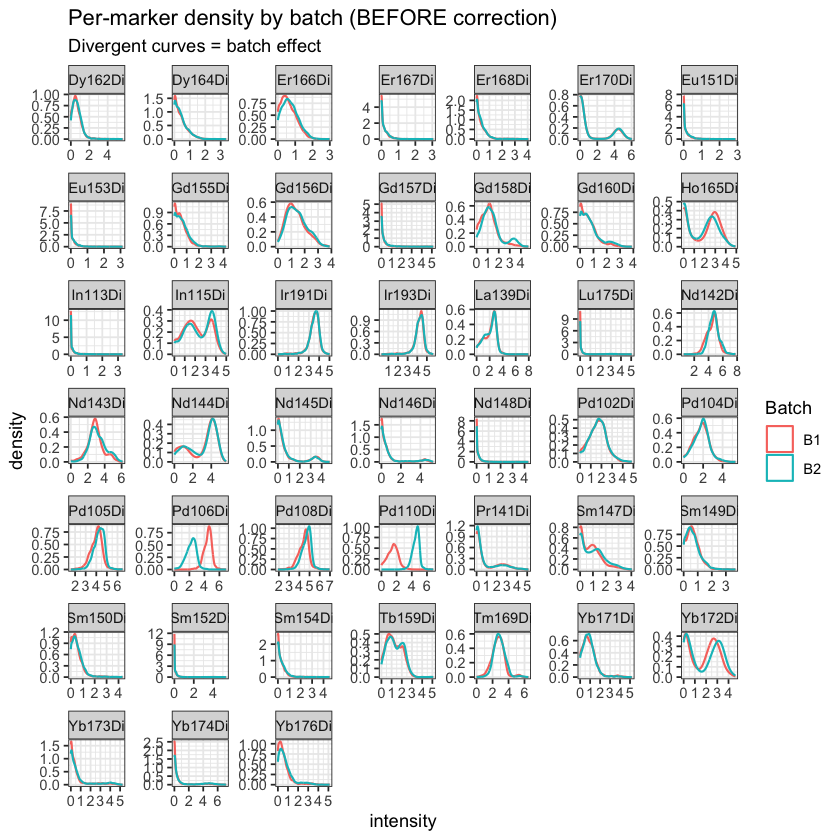

In [4]:
# Stack QC'd data across samples
df_qc <- bind_rows(lapply(seq_along(fs_qc), function(i) {
    d <- as.data.frame(exprs(fs_qc[[i]]))
    d$Sample <- sampleNames(fs_qc)[i]
    d$Batch  <- pData(fs_qc)$Batch[i]
    d
}))

# 1) Density overlays per batch — the canonical batch-effect plot
df_long <- df_qc %>%
    select(all_of(fluor_channels), Batch) %>%
    pivot_longer(-Batch, names_to = "marker", values_to = "intensity")

g_density <- ggplot(df_long, aes(x = intensity, color = Batch)) +
    geom_density(linewidth = 0.6) +
    facet_wrap(~marker, scales = "free") +
    theme_bw() +
    labs(title = "Per-marker density by batch (BEFORE correction)",
         subtitle = "Divergent curves = batch effect")
g_density

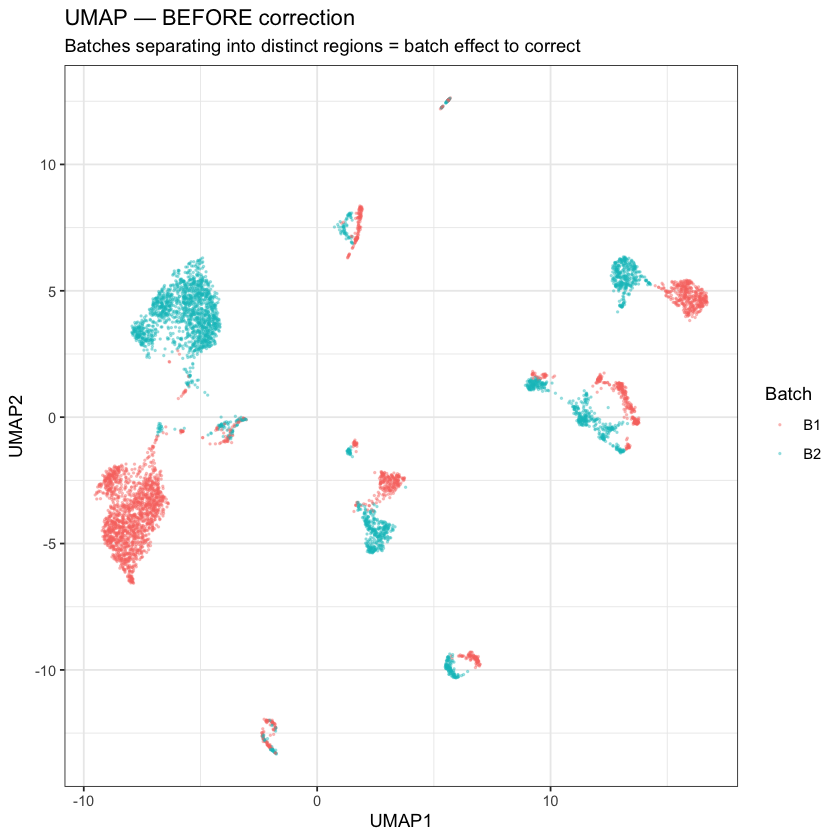

In [5]:
# 2) UMAP colored by batch
set.seed(42)
n_sub <- min(nrow(df_qc), 20000)
idx   <- sample(nrow(df_qc), n_sub)
mat   <- scale(as.matrix(df_qc[idx, fluor_channels]))
umap_before <- uwot::umap(mat, n_neighbors = 15, min_dist = 0.2)

umap_df <- data.frame(
    UMAP1 = umap_before[, 1],
    UMAP2 = umap_before[, 2],
    Batch = df_qc$Batch[idx],
    Sample = df_qc$Sample[idx]
)

ggplot(umap_df, aes(UMAP1, UMAP2, color = Batch)) +
    geom_point(alpha = 0.35, size = 0.3) +
    theme_bw() +
    labs(title = "UMAP — BEFORE correction",
         subtitle = "Batches separating into distinct regions = batch effect to correct")

## 5. Correct with cyCombine (general-purpose, no anchor required)

cyCombine's workflow:
1. **`prepare_data`** — pools FCS files, applies `arcsinh(x / cofactor)` transform, attaches metadata.
2. **`batch_correct`** — builds a self-organizing map across all cells, then runs ComBat *within each SOM node* (preserves biological structure while removing batch shifts).

**Key parameters:**
- `cofactor` — 5 for CyTOF, 150–500 for conventional fluorescence flow. Tune so populations look well-separated.
- `norm_method` — `"scale"` (default, gentler) or `"rank"` (heavier batch effects).
- `covar` — name of a biological condition column to *preserve* during ComBat.
- `xdim` × `ydim` — SOM grid size (8×8 = 64 nodes is a good default).

In [6]:
# cyCombine reads FCS files itself (it re-transforms with arcsinh), so we point
# it at the original (or margin-cleaned) files, NOT the logicle-transformed ones.

# Build an explicit panel mapping FCS detector channel → clean marker name.
# Two subtle requirements:
#   1. pData(parameters(ff)) has row names like "$P7N" — extracting `pm$name[i]`
#      returns a *named* character vector. data.frame() preserves those names
#      via AsIs, and a named vector passed to dplyr::all_of() selects by value
#      but RENAMES the output to the names attribute — silently breaking
#      cyCombine's internal column lookup. unname() strips it.
#   2. cyCombine's clean_colnames removes "-_ []()  {} \\" from antigen labels;
#      our panel must match that cleaning so prepare_data's marker check passes.
ff_first   <- read.FCS(fcs_files[1], transformation = FALSE, truncate_max_range = FALSE)
ff_first   <- fill_desc(ff_first)
param_meta <- pData(parameters(ff_first))

if (is_cytof) {
    marker_idx <- !is.na(param_meta$desc) & param_meta$desc != param_meta$name
} else {
    marker_idx <- !grepl("^(FSC|SSC|Time)", param_meta$name)
}
panel <- data.frame(
    fcs_colname = unname(param_meta$name[marker_idx]),
    antigen     = unname(stringr::str_remove_all(param_meta$desc[marker_idx],
                                                 "[-_ \\[\\](){}\\\\]")),
    stringsAsFactors = FALSE
)
markers <- unname(panel$antigen)
cat("cyCombine panel (", nrow(panel), " markers):\n", sep = ""); print(panel)

# derand = FALSE: the default (TRUE) only makes sense for CyTOF data with
# integer counts; on float values it fails marker lookup.
uncorrected <- prepare_data(
    data_dir      = fcs_dir,
    metadata      = metadata,
    filename_col  = "FCS_name",
    batch_ids     = "Batch",
    sample_ids    = "Sample",
    condition     = "condition",
    panel         = panel,
    panel_channel = "fcs_colname",
    panel_antigen = "antigen",
    markers       = markers,
    down_sample   = FALSE,
    cofactor      = cofactor,
    derand        = FALSE
)
cat("Uncorrected:", nrow(uncorrected), "cells across",
    length(unique(uncorrected$batch)), "batches\n")
head(uncorrected)


cyCombine panel (45 markers):
   fcs_colname     antigen
1      Pd102Di         BC1
2      Pd104Di         BC2
3      Pd105Di         BC3
4      Pd106Di         BC4
5      Pd108Di         BC5
6      Pd110Di         BC6
7      In113Di CD235abCD61
8      In115Di        CD45
9      La139Di        CD66
10     Pr141Di         CD7
11     Nd142Di        CD19
12     Nd143Di      CD45RA
13     Nd144Di       CD11b
14     Nd145Di         CD4
15     Nd146Di        CD8a
16     Sm147Di       CD11c
17     Nd148Di       CD123
18     Sm149Di        CREB
19     Sm150Di       STAT5
20     Eu151Di         p38
21     Sm152Di       TCRgd
22     Eu153Di       STAT1
23     Sm154Di       STAT3
24     Gd155Di          S6
25     Gd156Di       CXCR3
26     Gd157Di       CD161
27     Gd158Di        CD33
28     Tb159Di    MAPKAPK2
29     Gd160Di        Tbet
30     Dy162Di       FoxP3
31     Dy164Di         IkB
32     Ho165Di        CD16
33     Er166Di        NFkB
34     Er167Di         ERK
35     Er168Di        CCR

Preparing FCS files in directory ../data/batch_cytof

Reading 6 files to a flowSet..

Converting flowset to data frame

Extracting expression data..

Your flowset is now converted into a dataframe.

Transforming data using asinh with a cofactor of 5..

Done!



Uncorrected: 6000 cells across 2 batches


BC1,BC2,BC3,BC4,BC5,BC6,CD235abCD61,CD45,CD66,CD7,⋯,CCR2,HLADR,CD14,CD56,DNA1,DNA2,batch,sample,condition,id
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<fct>,<int>
1.9328234,1.693064,4.114009,4.641251,4.535402,2.124133,0.00000000,1.039118,2.3655929,0.3436128,⋯,0.25188522,0.12642084,0.079155343,0.4314862,3.650721,4.385232,B1,PTLG021_B1,PTLG021,1
0.8628199,1.188403,3.685567,4.097657,3.970385,1.040761,0.03931008,3.883058,0.8846833,2.7550642,⋯,0.04341859,0.00000000,0.000000000,0.5733980,3.159043,3.882595,B1,PTLG021_B1,PTLG021,2
2.6880796,2.374909,4.239577,4.609025,4.443633,1.867589,0.10691367,1.626927,2.4135548,0.2063238,⋯,0.22934838,0.00000000,0.002150116,0.7014516,3.921592,4.652472,B1,PTLG021_B1,PTLG021,3
1.4615917,1.930286,4.022274,4.383597,4.303142,1.659568,0.00000000,2.153729,3.2719599,0.1371461,⋯,1.18433323,0.00000000,0.000000000,1.0171695,3.537066,4.079680,B1,PTLG021_B1,PTLG021,4
1.1947370,1.537538,3.517538,3.877234,4.085259,1.384126,0.10453341,3.536531,0.5257996,0.9768644,⋯,1.48819727,0.46016320,0.000000000,0.7252887,3.496007,4.131132,B1,PTLG021_B1,PTLG021,5
2.1035038,2.323966,4.222271,4.862294,4.498180,1.545479,0.00000000,0.350065,2.7193972,0.1440839,⋯,0.05674371,0.02047993,0.000000000,0.3932919,3.773852,4.503869,B1,PTLG021_B1,PTLG021,6


In [7]:
corrected <- uncorrected %>%
    batch_correct(
        markers     = markers,
        norm_method = "scale",
        xdim        = 8,
        ydim        = 8,
        covar       = "condition",
        seed        = 42
    )
cat("Corrected:", nrow(corrected), "cells\n")
head(corrected)

Batch correcting using a SOM grid of dimensions 8x8

Scaling expression data..

Creating SOM grid..

Batch correcting data..

Correcting Label group 1

The label group almost exclusively consists of cells from a single covar. Therefore, covar is ignored for this label group

Found2batches

Adjusting for0covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data


Correcting Label group 2

Found2batches

Adjusting for2covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data


Correcting Label group 3

Found2batches

Adjusting for2covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data


Correcting Label group 4

Found2batches

Adjusting for2covariate(s) or covariate level(s)

Standardizing 

Found 3 genes with uniform expression within a single batch (all zeros); these will not be adjusted for batch.


Using the 'mean only' version of ComBat

Found2batches

Note: one batch has only one sample, setting mean.only=TRUE

Adjusting for0covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data


Correcting Label group 31

Found2batches

Adjusting for2covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data


Correcting Label group 32

Found2batches

Adjusting for2covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data


Correcting Label group 33

Found2batches

Adjusting for2covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data


Correcting Label group 34

Found2batches

Adjusting for2covar

Found 1 genes with uniform expression within a single batch (all zeros); these will not be adjusted for batch.


Found2batches

Adjusting for2covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data


Correcting Label group 40

Found2batches

Adjusting for2covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data


Correcting Label group 41

Found2batches

Adjusting for2covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data


Correcting Label group 42

Found2batches

Adjusting for2covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data


Correcting Label group 43

The label group almost exclusively consists of cells from a single covar. Therefore, covar is ignored for this label group



Found 2 genes with uniform expression within a single batch (all zeros); these will not be adjusted for batch.


Found2batches

Adjusting for0covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data


Correcting Label group 44

Covar is confounded with batch. Ignoring covar in this label group

Using the 'mean only' version of ComBat

Found2batches

Note: one batch has only one sample, setting mean.only=TRUE

Adjusting for0covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data


Correcting Label group 45

Found2batches

Adjusting for2covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data


Label group 46 only contains cells from batch B1

Correcting Label group 47

Found2batches

Adjusting for2covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding prio

Corrected: 6000 cells


id,BC1,BC2,BC3,BC4,BC5,BC6,CD235abCD61,CD45,CD66,⋯,CCR2,HLADR,CD14,CD56,DNA1,DNA2,batch,sample,condition,label
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<fct>,<fct>
1,1.9830796,1.718183,4.181899,3.900019,4.613400,3.064597,0.0100842336,0.9894117,2.3218016,⋯,0.30451894,0.149111393,0.082211248,0.4624678,3.641830,4.378631,B1,PTLG021_B1,PTLG021,35
2,0.8861501,1.210506,3.848365,3.033237,4.157939,2.561863,0.0440977391,3.9117285,0.9192440,⋯,0.10575695,0.000000000,0.001611055,0.5884189,3.155186,3.875691,B1,PTLG021_B1,PTLG021,31
3,2.7304847,2.410627,4.377716,3.827724,4.588171,2.976813,0.1317038800,1.5962176,2.4065262,⋯,0.24685561,0.005755347,0.007814093,0.7170332,3.921954,4.647956,B1,PTLG021_B1,PTLG021,11
4,1.4441605,1.920950,4.122040,3.649766,4.402411,2.635977,0.0002464832,2.1380250,3.2341526,⋯,1.22377452,0.000000000,0.004906347,1.0171898,3.504447,4.059272,B1,PTLG021_B1,PTLG021,1
5,1.2044260,1.560738,3.683417,2.774557,4.266453,2.849987,0.1138398776,3.5811808,0.5501685,⋯,1.63728046,0.538678739,0.001611055,0.7488287,3.481778,4.113133,B1,PTLG021_B1,PTLG021,31
6,2.0993892,2.359802,4.359893,4.119543,4.643393,2.694050,0.0141469517,0.3456201,2.7050185,⋯,0.05816823,0.027008993,0.005560627,0.4085345,3.773910,4.499497,B1,PTLG021_B1,PTLG021,11


## 6. Diagnostics — before vs. after

Three checks:
- **Density overlay** — batch curves should converge.
- **UMAP** — batches should overlap, biological structure should remain.
- **EMD reduction** — quantitative metric (>0 = correction helped). See [cyCombine benchmarking vignette](https://biosurf.org/cyCombine_benchmarking.html).

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the cyCombine package.
  Please report the issue to the authors.”
Picking joint bandwidth of 0.146

Picking joint bandwidth of 0.146

Picking joint bandwidth of 0.139

Picking joint bandwidth of 0.0909

Picking joint bandwidth of 0.114

Picking joint bandwidth of 0.0837

Picking joint bandwidth of 0.116

Picking joint bandwidth of 0.0183

Picking joint bandwidth of 0.223

Picking joint bandwidth of 0.167

Picking joint bandwidth of 0.186

Picking joint bandwidth of 0.129

Picking joint bandwidth of 0.15

Picking joint bandwidth of 0.279

Picking joint bandwidth of 0.0983

Picking joint bandwidth of 0.0837

Picking joint bandwidth of 0.148

Picking joint bandwidth of 0.0252

Picking joint bandwidth of 0.0819

Picking joint bandwidth of 0.0709

Picking joint bandwi

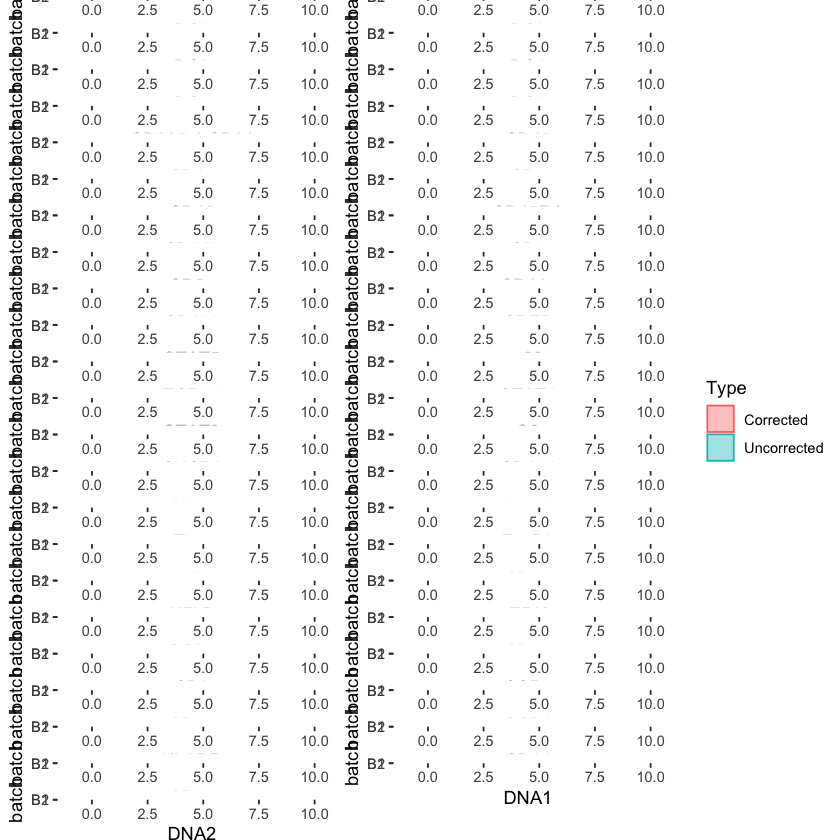

In [8]:
# cyCombine's built-in density comparison
plot_density(uncorrected, corrected, markers = markers, ncol = 2)

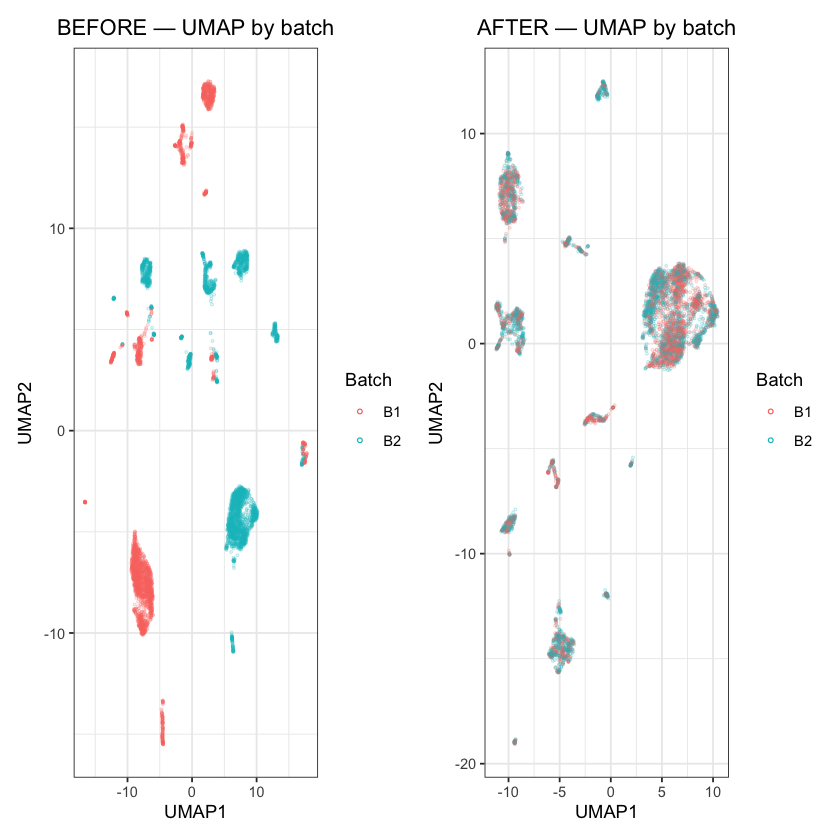

In [9]:
# UMAP before/after — colored by batch
set.seed(42)
n_plot <- min(nrow(uncorrected), 20000)
idx_u  <- sample(nrow(uncorrected), n_plot)
idx_c  <- sample(nrow(corrected),   n_plot)

p_before <- plot_dimred(uncorrected[idx_u, ], type = "umap", name = "Uncorrected") +
    ggtitle("BEFORE — UMAP by batch")
p_after  <- plot_dimred(corrected[idx_c, ],   type = "umap", name = "Corrected")   +
    ggtitle("AFTER — UMAP by batch")

p_before + p_after

In [10]:
# EMD (Earth Mover's Distance) reduction is cyCombine's headline metric:
#   reduction > 0 → batch effect was reduced.
# evaluate_emd needs the same SOM cluster column on both data frames. The
# cluster column produced by batch_correct() is named "label".
# batch_correct() preserves row order, so we copy the labels across.
tryCatch({
    uncorrected_eval <- uncorrected
    uncorrected_eval$label <- corrected$label

    emd <- evaluate_emd(uncorrected_eval, corrected,
                        cell_col = "label", markers = markers, binSize = 0.1)
    cat("Mean EMD reduction:", round(emd$reduction, 3),
        "  (positive = batch effect reduced)\n")
    print(head(emd$emd))
}, error = function(e) {
    message("evaluate_emd failed (often happens with very small demo data): ",
            conditionMessage(e))
})


Computing EMD for corrected data..

Binning destributions using binSize 0.1

Computing marker-wise EMD for each cell cluster

Computing EMD for uncorrected data..

Binning destributions using binSize 0.1

Computing marker-wise EMD for each cell cluster

Removing EMDs below 2 both before and after correction

The reduction is: 0.72

Creating plots..

Evaluation complete.



Mean EMD reduction: 0.72   (positive = batch effect reduced)
# A tibble: 6 × 4
  Name   Corrected Uncorrected Reduction
  <chr>      <dbl>       <dbl>     <dbl>
1 1.BC13     0.999       0.941   -0.0580
2 1.BC23     0.584       0.637    0.0532
3 1.BC33     0.284       3.11     2.83  
4 1.BC43     0.311      22.3     22.0   
5 1.BC53     0.274       3.29     3.01  
6 1.BC63     0.851      30.8     30.0   


## 7. Alternative — CytoNorm (when you have anchor controls)

If every batch contains the same aliquoted reference sample (e.g., a frozen PBMC pool), CytoNorm typically outperforms ComBat-based methods. It trains a per-cluster quantile spline that maps each batch's reference back to a common goal distribution, then applies the same transform to all other samples in the batch.

**Required metadata:** add a `Type` column with values `Train` (anchor controls) and `Validation` (samples to correct).

Skip this section if you don't have anchor controls — `cyCombine` from section 5 is your correction.

In [11]:
# Run if metadata has a `Type` column with Train/Validation labels.
# In the CytoNorm demo, PTLG021 + PTLG028 are training anchors (same patient
# across both batches), and PTLG034 is the held-out validation sample.
has_anchors <- "Type" %in% colnames(metadata) && any(metadata$Type == "Train")

if (has_anchors) {
    train_data <- metadata %>% filter(Type == "Train")
    val_data   <- metadata %>% filter(Type == "Validation")

    # Same transform family as section 3: arcsinh for CyTOF, logicle for fluor.
    if (is_cytof) {
        tl     <- transformList(fluor_channels, arcsinhTransform(a = 0, b = 1 / cofactor, c = 0))
        tl_rev <- transformList(fluor_channels, function(x) sinh(x) * cofactor)
    } else {
        tl     <- transformList(fluor_channels, logicleTransform())
        tl_rev <- transformList(fluor_channels, inverseLogicleTransform(trans = logicleTransform()))
    }

    model <- CytoNorm.train(
        files            = file.path(fcs_dir, train_data$FCS_name),
        labels           = train_data$Batch,
        channels         = fluor_channels,
        transformList    = tl,
        FlowSOM.params   = list(nCells = min(6000, sum(fsApply(fs, nrow))),
                                xdim = 5, ydim = 5, nClus = 10, scale = FALSE),
        normMethod.train = QuantileNorm.train,
        normParams       = list(nQ = 101, goal = "mean"),
        seed             = 42,
        verbose          = TRUE
    )

    out_norm <- file.path("../data/results", "04_cytonorm_normalized")
    dir.create(out_norm, showWarnings = FALSE, recursive = TRUE)
    CytoNorm.normalize(
        model                 = model,
        files                 = file.path(fcs_dir, val_data$FCS_name),
        labels                = val_data$Batch,
        transformList         = tl,
        transformList.reverse = tl_rev,
        normMethod.normalize  = QuantileNorm.normalize,
        outputDir             = out_norm,
        prefix                = "Norm_",
        verbose               = TRUE
    )
    cat("CytoNorm output:", out_norm, "\n")
} else {
    message("No 'Type' column with 'Train' anchors — skipping CytoNorm. Use cyCombine output (section 5).")
}

Reading ../data/batch_cytof/Gates_PTLG021_Unstim_Control_1.fcs

Reading ../data/batch_cytof/Gates_PTLG021_Unstim_Control_2.fcs

Reading ../data/batch_cytof/Gates_PTLG028_Unstim_Control_1.fcs

Reading ../data/batch_cytof/Gates_PTLG028_Unstim_Control_2.fcs

Splitting ../data/batch_cytof/Gates_PTLG021_Unstim_Control_1.fcs

Splitting ../data/batch_cytof/Gates_PTLG021_Unstim_Control_2.fcs

Splitting ../data/batch_cytof/Gates_PTLG028_Unstim_Control_1.fcs

Splitting ../data/batch_cytof/Gates_PTLG028_Unstim_Control_2.fcs

Processing cluster 1

Computing Quantiles

  B1 (FileID 1,3)

Reading ./tmp/.._data_batch_cytof_Gates_PTLG021_Unstim_Control_1.fcs_fsom1.fcs

Reading ./tmp/.._data_batch_cytof_Gates_PTLG028_Unstim_Control_1.fcs_fsom1.fcs

  Less then 50 cells in B1 (44). No quantiles computed.

  B2 (FileID 2,4)

Reading ./tmp/.._data_batch_cytof_Gates_PTLG021_Unstim_Control_2.fcs_fsom1.fcs

Reading ./tmp/.._data_batch_cytof_Gates_PTLG028_Unstim_Control_2.fcs_fsom1.fcs

  Less then 50 cells i

CytoNorm output: ../data/results/04_cytonorm_normalized 


## 8. Save corrected data

cyCombine returns a `data.frame` keyed on `sample` + `batch`. We round-trip it back to FCS files (one per sample), so downstream tooling can pick up the corrected expression without modification.

In [12]:
out_dir <- "../data/results/04_corrected_fcs"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

# Reverse cyCombine's arcsinh(x/cofactor) so saved FCS values are on the original scale.
for (s in unique(corrected$sample)) {
    cells <- corrected %>% filter(sample == s)
    expr  <- sinh(as.matrix(cells[, markers])) * cofactor
    ff_out <- flowFrame(expr)
    write.FCS(ff_out, file.path(out_dir, paste0("corrected_", s, ".fcs")))
}

# Also save the long-format data.frame for downstream analysis
write.csv(corrected,   file.path("../data/results", "04_corrected_long.csv"),   row.names = FALSE)
write.csv(uncorrected, file.path("../data/results", "04_uncorrected_long.csv"), row.names = FALSE)
write.csv(qc_summary,  file.path("../data/results", "04_qc_summary.csv"),       row.names = FALSE)
if (exists("emd")) write.csv(emd$emd, file.path("../data/results", "04_emd.csv"))

cat("Saved corrected FCS files to:", out_dir, "\n")
cat("Downstream: feed these into notebook 03 for clustering on corrected data.\n")

Saved corrected FCS files to: ../data/results/04_corrected_fcs 
Downstream: feed these into notebook 03 for clustering on corrected data.
